# 2026-08-04 Initial Check: rSFMS distributions by infall stage

This notebook compares the resolved star-forming main sequence (rSFMS) for the
full selected MAUVE sample and the three infall stages from
`mauve_master_wiki_newclass.fits`. After the combined rSFMS plot, two
area-normalized histograms compare the shapes of the selected spaxel
distributions in log stellar-mass surface density and log SFR surface density.


## Setup

The analysis discovers current products below `v3tk_v7.6.8` and selects finite
HII-region SFR and stellar-mass pixels with EW(Halpha) > 6 Angstrom and
intrinsic Halpha dispersion < 45 km/s. `NGC4567_8` inherits an infall class only
when both component galaxies have the same class. Histogram curves are
normalized independently to unit area, so they compare distribution shapes
rather than the different numbers of spaxels in each sample.


In [1]:
# Current further-project products used by the post-peak rSFMS analysis.
from __future__ import annotations

from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
OUTDIR = PROJECT_ROOT / "quicklook_figures_further"

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Current further run directory: {RUN_DIR}")
print("Active save paths are intentionally commented out in this notebook.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Current further run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Active save paths are intentionally commented out in this notebook.


In [2]:
def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(
        p for p in run_dir.iterdir()
        if p.is_dir() and not p.name.endswith("_logs")
    ):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        gas_raw_lower = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_raw_upper = gal_dir / f"{gal}_gas_BIN_maps.fits"
        gas_further_lower = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_further_upper = gal_dir / f"{gal}_gas_BIN_maps_further.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_raw)
        gas_preferred = first_existing(gas_further_lower, gas_further_upper, gas_raw_lower, gas_raw_upper)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "ew_path": first_existing(gal_dir / f"{gal}_proxy_EW_maps_further.fits", gal_dir / f"{gal}_proxy_EW_maps.fits"),
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "sfr_log_path": first_existing(RUN_DIR / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(RUN_DIR / "mass_logs" / f"{gal}.log"),
            "source": "further",
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further_lower.exists() or gas_further_upper.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table



CURRENT_PRODUCTS = discover_further_products()

CURRENT_READY_PHYSICS_GALAXIES = CURRENT_PRODUCTS.index[CURRENT_PRODUCTS["ready_physics_maps"]].tolist()
CURRENT_NOT_PHYSICS_READY = CURRENT_PRODUCTS.index[~CURRENT_PRODUCTS["ready_physics_maps"]].tolist()

FAKE_GALAXIES = []
UNREUSABLE_MISSING_GALAXIES = CURRENT_NOT_PHYSICS_READY

PRODUCTS = CURRENT_PRODUCTS.copy()
PRODUCTS["source"] = "further_ready"
PRODUCTS.loc[~PRODUCTS["ready_physics_maps"], "source"] = "further_not_science_ready"
PRODUCTS["fake_reason"] = ""
PRODUCTS.loc[UNREUSABLE_MISSING_GALAXIES, "fake_reason"] = "kept for inventory/QC only; not science-ready in current further products"

ANALYSIS_GALAXIES = CURRENT_READY_PHYSICS_GALAXIES
QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_QC_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
DISPLAY_COLUMNS = [
    "source",
    "has_spatial",
    "has_gas",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "spatial_path",
    "gas_path",
    "ew_path",
    "sfr_log_path",
    "mass_log_path",
    "fake_reason",
]

print(f"Discovered current galaxy folders: {len(CURRENT_PRODUCTS)}")
print(f"Science-ready current further galaxies: {len(CURRENT_READY_PHYSICS_GALAXIES)}")
print(f"Not science-ready current further galaxies: {len(CURRENT_NOT_PHYSICS_READY)}")
print("Extended fallback galaxies: 0 (disabled; using current further products only)")
print("Analysis galaxies:", ", ".join(ANALYSIS_GALAXIES))
print("Current not-science-ready galaxies:", ", ".join(UNREUSABLE_MISSING_GALAXIES) if UNREUSABLE_MISSING_GALAXIES else "none")
display(PRODUCTS[DISPLAY_COLUMNS])

def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    if galaxy in PRODUCTS.index and PRODUCTS.loc[galaxy, "ew_path"] is not None:
        return Path(PRODUCTS.loc[galaxy, "ew_path"])

    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps.fits", "_proxy_EW_maps_further.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.append(RUN_DIR / galaxy / f"{galaxy}{suffix_item}")
        candidates.append(PROJECT_ROOT / f"{galaxy}{suffix_item}")
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def sfr_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "sfr_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "sfr_logs" / f"{galaxy}.log")


def mass_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "mass_log_path"]
        return None if path is None else Path(path)
    return first_existing(RUN_DIR / "mass_logs" / f"{galaxy}.log")


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0


COMBINED_GALAXY_COMPONENTS = {
    "NGC4567_8": ("NGC4567", "NGC4568"),
}


def add_combined_infall_classes(infall_classes: dict[str, int]) -> dict[str, int]:
    """Assign a combined product only when all components share one stage."""
    resolved = dict(infall_classes)
    for combined_id, components in COMBINED_GALAXY_COMPONENTS.items():
        missing = [component for component in components if component not in resolved]
        if missing:
            raise KeyError(
                f"Cannot classify {combined_id}: missing components {', '.join(missing)}"
            )
        component_stages = {resolved[component] for component in components}
        if len(component_stages) != 1:
            details = ", ".join(
                f"{component}=stage {resolved[component]}" for component in components
            )
            raise ValueError(f"Cannot classify {combined_id}: {details}")
        resolved[combined_id] = component_stages.pop()
    return resolved




Discovered current galaxy folders: 35
Science-ready current further galaxies: 35
Not science-ready current further galaxies: 0
Extended fallback galaxies: 0 (disabled; using current further products only)
Analysis galaxies: IC3392, NGC4064, NGC4189, NGC4192, NGC4222, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4321, NGC4330, NGC4351, NGC4380, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4424, NGC4450, NGC4457, NGC4501, NGC4522, NGC4535, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4654, NGC4694, NGC4698
Current not-science-ready galaxies: none


,source,has_spatial,has_gas,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,spatial_path,gas_path,ew_path,sfr_log_path,mass_log_path,fake_reason
galaxy,,,,,,,,,,,,,,,,,,
IC3392,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4064,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4189,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4192,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4222,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4254,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4293,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4294,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,
NGC4298,further_ready,True,True,True,True,True,True,True,True,True,False,True,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,/Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8...,


In [3]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


,Fit,Method,alpha,beta,N_spaxels,RMSE,R_squared
0,Pessa+21 (published),Published,1.050,-10.630,--,--,--
1,MAUVE all infall stages,OLS,0.803,-8.500,"3,196,545",0.474,0.408
2,MAUVE pre-peak,OLS,0.877,-9.011,"2,018,820",0.481,0.423


Selected full-sample HII spaxels (EW(Ha)>6 A, intrinsic sigma<45 km/s): 3,196,545


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_43439/1238871763.py:357: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.85])


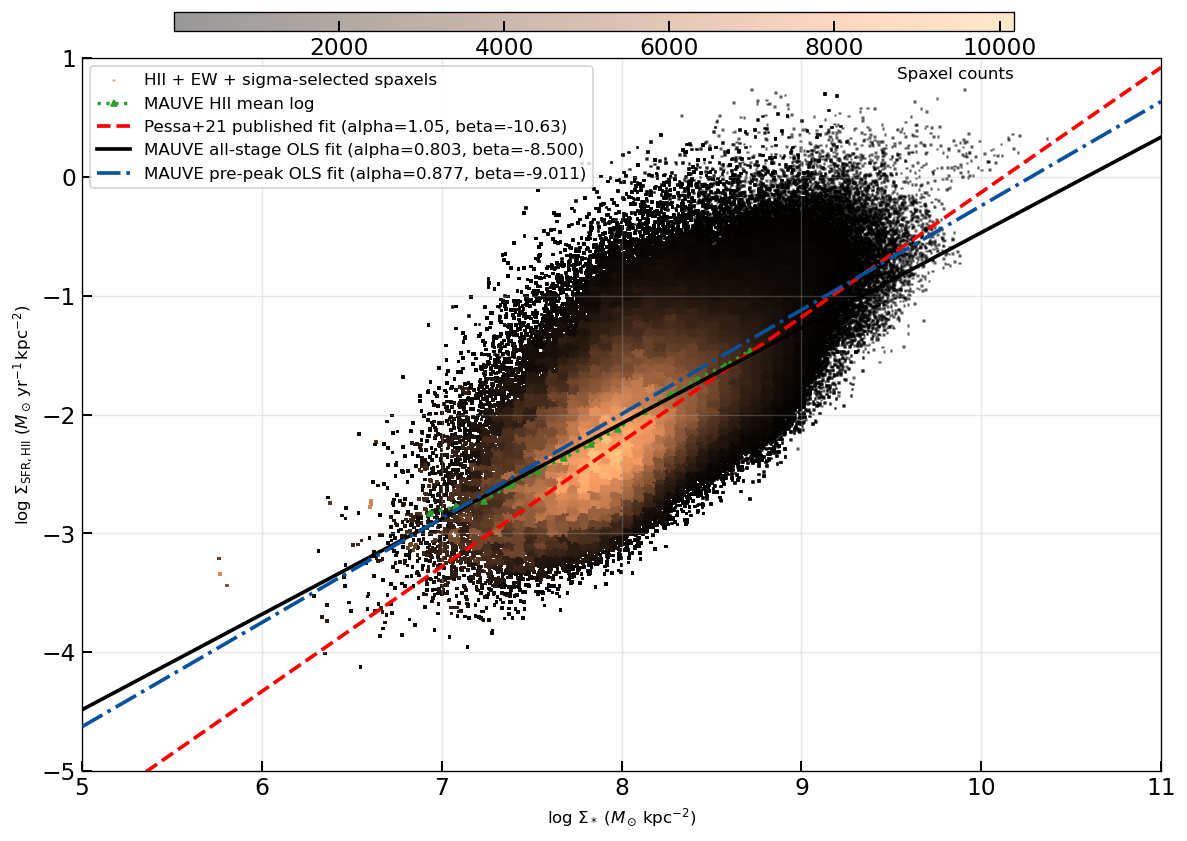

In [4]:
# ------------------------------------------------------------------
# COMBINED PLOT - rSFMS with consistent HII + EW + sigma selection
# Current full further sample, independent of infall stage
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

EW_HDU = "PROXY_EWHA"
EW_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0


def load_selected_rsfms_maps(galaxy):
    """Load and align the four maps needed by the shared rSFMS selection."""
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)
    ew_path = further_ew_path(galaxy)

    with fits.open(spatial_path) as hdul:
        log_sigma_m = np.asarray(
            hdul["LOGMASS_SURFACE_DENSITY"].data, dtype=float
        )
    with fits.open(gas_path) as hdul:
        log_sigma_sfr = np.asarray(
            hdul["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float
        )
        halpha_sigma_obs = np.asarray(hdul["HA6562_SIGMA"].data, dtype=float)
        halpha_sigma_corr = np.asarray(
            hdul["HA6562_SIGMA_CORR"].data, dtype=float
        )
    with fits.open(ew_path) as hdul:
        ew_ha = np.asarray(hdul[EW_HDU].data, dtype=float)

    target_shape = log_sigma_sfr.shape
    log_sigma_m = align_map_to_shape(
        log_sigma_m, target_shape, label=f"{galaxy} stellar mass"
    )
    ew_ha = align_map_to_shape(
        ew_ha, target_shape, label=f"{galaxy} {EW_HDU}"
    )
    halpha_sigma_obs = align_map_to_shape(
        halpha_sigma_obs, target_shape, label=f"{galaxy} HA6562_SIGMA"
    )
    halpha_sigma_corr = align_map_to_shape(
        halpha_sigma_corr, target_shape, label=f"{galaxy} HA6562_SIGMA_CORR"
    )

    sigma2_intrinsic = halpha_sigma_obs**2 - halpha_sigma_corr**2
    halpha_sigma = np.full(target_shape, np.nan, dtype=float)
    sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    halpha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
    return log_sigma_m, log_sigma_sfr, ew_ha, halpha_sigma


def selected_rsfms_mask(log_sigma_m, log_sigma_sfr, ew_ha, halpha_sigma):
    """Select HII spaxels with EW(Halpha)>6 A and intrinsic sigma<45 km/s."""
    return (
        np.isfinite(log_sigma_m)
        & np.isfinite(log_sigma_sfr)
        & np.isfinite(ew_ha)
        & (ew_ha > EW_MIN)
        & np.isfinite(halpha_sigma)
        & (halpha_sigma < HALPHA_SIGMA_MAX)
    )


def binned_rsfms_mean_trend(x, y, *, bin_width, min_pixels):
    """Bin the central 95% in mass and preserve gaps between valid bins."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]
    trend_lo, trend_hi = np.nanpercentile(x, [2.5, 97.5])
    central = (x >= trend_lo) & (x <= trend_hi)
    x_data = x[central]
    y_data = y[central]

    edges = np.arange(trend_lo, trend_hi, bin_width)
    if edges.size == 0:
        edges = np.asarray([trend_lo])
    if edges[-1] < trend_hi:
        edges = np.append(edges, trend_hi)

    trend_x = []
    mean_log = []
    counts = []
    last_bin = len(edges) - 2
    for index, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        if index == last_bin:
            in_bin = (x_data >= left) & (x_data <= right)
        else:
            in_bin = (x_data >= left) & (x_data < right)
        count = int(np.count_nonzero(in_bin))
        counts.append(count)
        if count < min_pixels:
            trend_x.append(0.5 * (left + right))
            mean_log.append(np.nan)
            continue

        x_bin = x_data[in_bin]
        y_bin = y_data[in_bin]
        trend_x.append(np.mean(x_bin))
        mean_log.append(np.mean(y_bin))

    return (
        np.asarray(trend_x),
        np.asarray(mean_log),
        np.asarray(counts, dtype=int),
        (trend_lo, trend_hi),
    )



def ols_rsfms_fit(x, y):
    """Fit log Sigma_SFR = alpha * log Sigma_* + beta by OLS."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    finite = np.isfinite(x) & np.isfinite(y)
    x_fit = x[finite]
    y_fit = y[finite]
    if x_fit.size < 2:
        raise ValueError("At least two finite spaxels are required for OLS")

    design = np.column_stack((x_fit, np.ones_like(x_fit)))
    alpha, beta = np.linalg.lstsq(design, y_fit, rcond=None)[0]
    residuals = y_fit - (alpha * x_fit + beta)
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((y_fit - np.mean(y_fit))**2)
    return {
        "alpha": float(alpha),
        "beta": float(beta),
        "n_spaxels": int(x_fit.size),
        "rmse": float(np.sqrt(np.mean(residuals**2))),
        "r_squared": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
    }

# Discover every current further galaxy with mass, HII-SFR, and EW maps.
full_sample_galaxies = PRODUCTS.index[
    PRODUCTS["has_mass_map"]
    & PRODUCTS["has_sfr_map"]
    & PRODUCTS["has_proxy_ew"]
].tolist()


with fits.open(PROJECT_ROOT / "mauve_master_wiki_newclass.fits") as hdul:
    full_sample_infall_class = {
        row["Galaxy"].strip(): int(row["class"])
        for row in hdul[1].data
    }
full_sample_infall_class = add_combined_infall_classes(full_sample_infall_class)

all_x_full = []
all_y_full = []
all_x_infall_stages = []
all_y_infall_stages = []
all_x_pre_peak = []
all_y_pre_peak = []
full_sample_galaxy_counts = {}

for galaxy in full_sample_galaxies:
    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, log_sigma_sfr, _, _ = maps

    if np.any(selected):
        x_det = log_sigma_m[selected]
        y_det = log_sigma_sfr[selected]
        all_x_full.extend(x_det.ravel())
        all_y_full.extend(y_det.ravel())
        stage = full_sample_infall_class.get(galaxy)
        if stage in (1, 2, 3):
            all_x_infall_stages.extend(x_det.ravel())
            all_y_infall_stages.extend(y_det.ravel())
        if stage == 1:
            all_x_pre_peak.extend(x_det.ravel())
            all_y_pre_peak.extend(y_det.ravel())
        full_sample_galaxy_counts[galaxy] = int(x_det.size)
    else:
        full_sample_galaxy_counts[galaxy] = 0
        print(f"Skipping {galaxy}: no HII+EW+sigma-selected spaxels")

all_x_full = np.asarray(all_x_full, dtype=float)
all_y_full = np.asarray(all_y_full, dtype=float)
if all_x_full.size == 0:
    raise RuntimeError("No valid HII+EW+sigma rSFMS data found.")


all_x_infall_stages = np.asarray(all_x_infall_stages, dtype=float)
all_y_infall_stages = np.asarray(all_y_infall_stages, dtype=float)
all_x_pre_peak = np.asarray(all_x_pre_peak, dtype=float)
all_y_pre_peak = np.asarray(all_y_pre_peak, dtype=float)
if all_x_infall_stages.size == 0:
    raise RuntimeError("No valid class 1-3 spaxels found for the all-stage OLS fit.")
if all_x_pre_peak.size == 0:
    raise RuntimeError("No valid pre-peak spaxels found for the OLS fit.")

mauve_all_fit = ols_rsfms_fit(all_x_infall_stages, all_y_infall_stages)
mauve_pre_peak_fit = ols_rsfms_fit(all_x_pre_peak, all_y_pre_peak)
mauve_all_alpha = mauve_all_fit["alpha"]
mauve_all_intercept = mauve_all_fit["beta"]
mauve_pre_peak_alpha = mauve_pre_peak_fit["alpha"]
mauve_pre_peak_intercept = mauve_pre_peak_fit["beta"]

pessa_alpha_full = 1.05
pessa_intercept_full = -10.63
rsfms_fit_results = pd.DataFrame(
    [
        {
            "Fit": "Pessa+21 (published)",
            "Method": "Published",
            "alpha": pessa_alpha_full,
            "beta": pessa_intercept_full,
            "N_spaxels": "--",
            "RMSE": np.nan,
            "R_squared": np.nan,
        },
        {
            "Fit": "MAUVE all infall stages",
            "Method": "OLS",
            "alpha": mauve_all_alpha,
            "beta": mauve_all_intercept,
            "N_spaxels": f"{mauve_all_fit['n_spaxels']:,}",
            "RMSE": mauve_all_fit["rmse"],
            "R_squared": mauve_all_fit["r_squared"],
        },
        {
            "Fit": "MAUVE pre-peak",
            "Method": "OLS",
            "alpha": mauve_pre_peak_alpha,
            "beta": mauve_pre_peak_intercept,
            "N_spaxels": f"{mauve_pre_peak_fit['n_spaxels']:,}",
            "RMSE": mauve_pre_peak_fit["rmse"],
            "R_squared": mauve_pre_peak_fit["r_squared"],
        },
    ]
)
display(
    rsfms_fit_results.style.format(
        {"alpha": "{:.3f}", "beta": "{:.3f}", "RMSE": "{:.3f}", "R_squared": "{:.3f}"},
        na_rep="--",
    )
)


print(
    "Selected full-sample HII spaxels "
    f"(EW(Ha)>{EW_MIN:g} A, intrinsic sigma<{HALPHA_SIGMA_MAX:g} km/s): "
    f"{all_y_full.size:,}"
)

fig, ax_combined = plt.subplots(figsize=(10, 8))

# Density-colored scatter of all selected pixels.
H, xedges, yedges = np.histogram2d(
    all_x_full,
    all_y_full,
    bins=100,
    range=[[5, 11], [-5, 1]],
)
x_idx = np.clip(np.digitize(all_x_full, xedges) - 1, 0, H.shape[0] - 1)
y_idx = np.clip(np.digitize(all_y_full, yedges) - 1, 0, H.shape[1] - 1)
density = H[x_idx, y_idx]

scatter = ax_combined.scatter(
    all_x_full,
    all_y_full,
    c=density,
    s=1,
    alpha=0.4,
    marker=",",
    cmap="copper",
    label="HII + EW + sigma-selected spaxels",
    zorder=1,
)

# The mean-log trend uses exact percentile bounds. NaNs preserve gaps where a bin
# contains fewer than 50 selected pixels, preventing unsupported line segments.
(
    trend_x_full,
    mean_log_hii_full,
    trend_counts_full,
    (trend_lo_full, trend_hi_full),
) = binned_rsfms_mean_trend(
    all_x_full,
    all_y_full,
    bin_width=0.15,
    min_pixels=50,
)
bin_width = 0.15
min_pixels_per_bin = 50

ax_combined.plot(
    trend_x_full,
    mean_log_hii_full,
    color="tab:green",
    linestyle=":",
    marker="^",
    markersize=3.6,
    linewidth=2.0,
    label="MAUVE HII mean log",
    zorder=7,
)


x_rsfms_fit_full = np.linspace(5, 11, 200)
ax_combined.plot(
    x_rsfms_fit_full,
    pessa_alpha_full * x_rsfms_fit_full + pessa_intercept_full,
    color="red",
    linestyle="--",
    linewidth=2.2,
    label="Pessa+21 published fit (alpha=1.05, beta=-10.63)",
    zorder=8,
)
ax_combined.plot(
    x_rsfms_fit_full,
    mauve_all_alpha * x_rsfms_fit_full + mauve_all_intercept,
    color="black",
    linestyle="-",
    linewidth=2.2,
    label=(
        f"MAUVE all-stage OLS fit "
        f"(alpha={mauve_all_alpha:.3f}, beta={mauve_all_intercept:.3f})"
    ),
    zorder=9,
)
ax_combined.plot(
    x_rsfms_fit_full,
    mauve_pre_peak_alpha * x_rsfms_fit_full + mauve_pre_peak_intercept,
    color="#08519C",
    linestyle="-.",
    linewidth=2.2,
    label=(
        f"MAUVE pre-peak OLS fit "
        f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
    ),
    zorder=10,
)

ax_combined.set_xlabel(r"$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$")
ax_combined.set_ylabel(
    r"$\log\,\Sigma_{\mathrm{SFR,HII}}\; "
    r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
)
ax_combined.set_xlim(5, 11)
ax_combined.set_ylim(-5, 1)
ax_combined.grid(True, alpha=0.3)
ax_combined.legend(
    loc="upper left", ncol=1, frameon=True, framealpha=0.85
)

cbar_ax = fig.add_axes([0.15, 0.85, 0.7, 0.02])
cbar = plt.colorbar(scatter, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Spaxel counts", loc="right")
plt.tight_layout(rect=[0, 0, 1, 0.85])
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "rSFMS_combined_full_further.pdf", bbox_inches="tight")
plt.show()


## Post-peak resolved star-forming main sequence

Pale cyan-blue points are the pooled post-peak HII-region spaxels. The summary
curve follows the detected-pixel definition in cell 25 of
`20260412_Plot_Paper_1_referee.ipynb`: the mean log Σ_SFR in 0.15 dex
stellar-mass bins. The reference curve is the MAUVE pre-peak OLS fit measured in cell 6
with the same selected-spaxel definition.


  IC3392: 13,897 Post-peak selected spaxels
  NGC4064: 3,273 Post-peak selected spaxels
  NGC4189: 96,364 Pre-peak selected spaxels
  NGC4192: 144,333 Pre-peak selected spaxels
  NGC4222: 42,249 Pre-peak selected spaxels
  NGC4254: 661,963 Pre-peak selected spaxels
  NGC4293: 471 Post-peak selected spaxels
  NGC4294: 68,833 Pre-peak selected spaxels
  NGC4298: 144,157 Close-to-peak selected spaxels
  NGC4302: 27,304 Close-to-peak selected spaxels
  NGC4321: 454,131 Pre-peak selected spaxels
  NGC4330: 35,688 Close-to-peak selected spaxels
  NGC4351: 30,711 Pre-peak selected spaxels
  NGC4380: 64,097 Post-peak selected spaxels
  NGC4383: 25,212 Pre-peak selected spaxels
  NGC4388: 17,663 Close-to-peak selected spaxels
  NGC4394: 31,915 Post-peak selected spaxels
  NGC4396: 85,378 Pre-peak selected spaxels
  NGC4402: 46,769 Close-to-peak selected spaxels
  NGC4405: 13,569 Post-peak selected spaxels
  NGC4419: 5,763 Post-peak selected spaxels
  NGC4424: 8,994 Close-to-peak selected spaxel

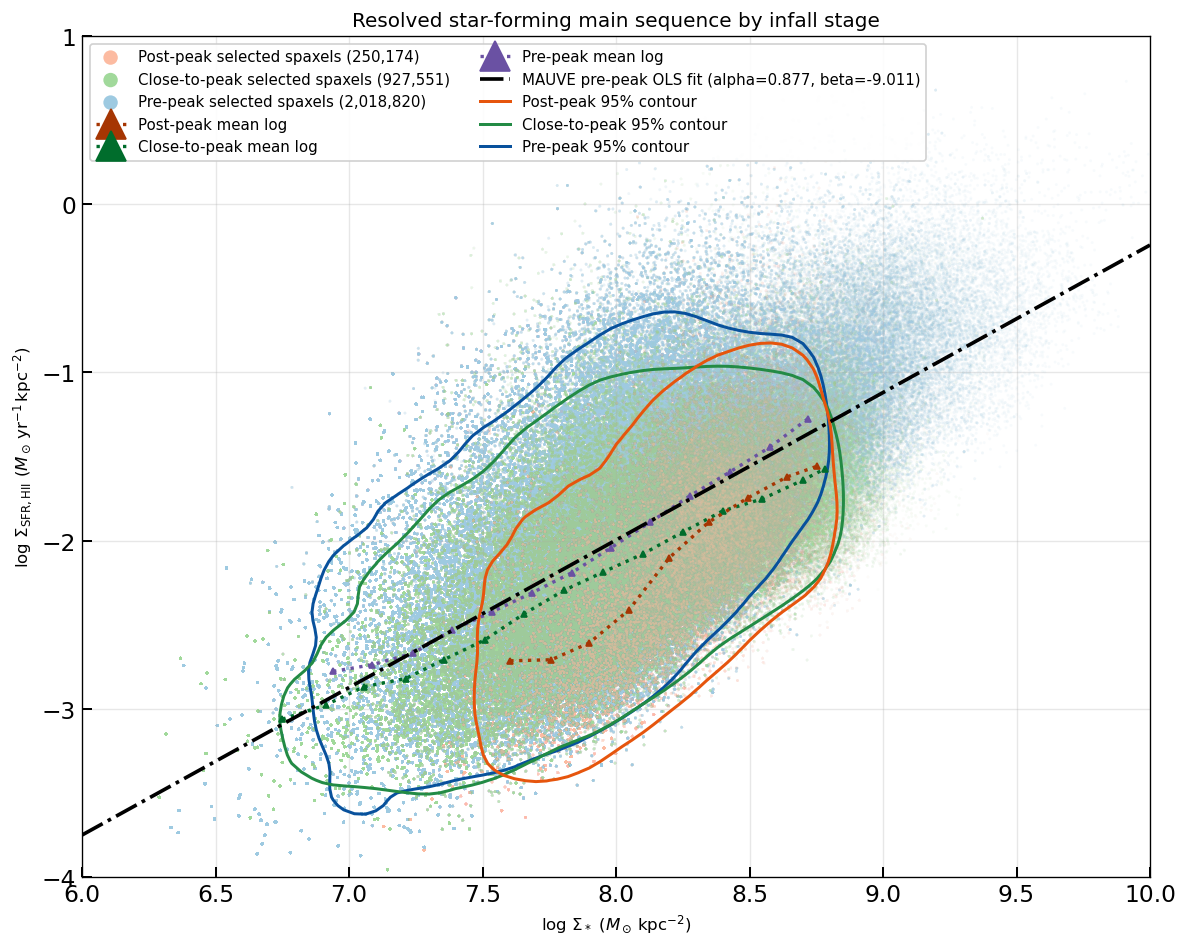


rSFMS sample by infall stage:
  Pre-peak: 2,018,820 spaxels from 11 galaxies
  Close-to-peak: 927,551 spaxels from 10 galaxies
  Post-peak: 250,174 spaxels from 14 galaxies
Selection: HII + EW(Ha)>6 A + intrinsic sigma<45 km/s
Trends: central 95% in stellar mass, 0.15-dex bins, >=50 pixels per bin


In [5]:
# Add pre-peak and close-to-peak samples using the same selection.
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter

RSFMS_XRANGE = (6.0, 10.0)
RSFMS_YRANGE = (-4.0, 1.0)
RSFMS_BIN_WIDTH = 0.15
RSFMS_MIN_PIXELS_PER_BIN = 50

RSFMS_STAGE_LABELS = {
    1: "Pre-peak",
    2: "Close-to-peak",
    3: "Post-peak",
}
RSFMS_STAGE_STYLE = {
    1: {
        "scatter": "#9ECAE1",
        "contour": "#08519C",
        "mean_log": "#6A51A3",
        "alpha": 0.08,
        "zorder": 1.0,
    },
    2: {
        "scatter": "#A1D99B",
        "contour": "#238B45",
        "mean_log": "#006D2C",
        "alpha": 0.035,
        "zorder": 2.0,
    },
    3: {
        "scatter": "#FCBBA1",
        "contour": "#E6550D",
        "mean_log": "#A63603",
        "alpha": 0.025,
        "zorder": 3.0,
    },
}
STAGE_CONTOUR_ZORDER = 4.0
STAGE_TREND_ZORDER = 6.0
RSFMS_CONTOUR_BINS = 100
RSFMS_CONTOUR_SMOOTHING = 2.0

stage_log_sigma_m = {stage: [] for stage in (1, 2, 3)}
stage_log_sigma_sfr = {stage: [] for stage in (1, 2, 3)}
stage_galaxies = {stage: [] for stage in (1, 2, 3)}

print("Collecting selected HII spaxels for all three infall stages...")
for galaxy in full_sample_galaxies:
    stage = full_sample_infall_class.get(galaxy)
    if stage not in (1, 2, 3):
        continue

    try:
        maps = load_selected_rsfms_maps(galaxy)
        selected = selected_rsfms_mask(*maps)
        log_sigma_m, log_sigma_sfr, _, _ = maps
    except Exception as exc:
        print(f"  {galaxy}: skipped - {exc}")
        continue

    n_spaxels = int(selected.sum())
    print(f"  {galaxy}: {n_spaxels:,} {RSFMS_STAGE_LABELS[stage]} selected spaxels")
    if n_spaxels == 0:
        continue
    stage_galaxies[stage].append(galaxy)
    stage_log_sigma_m[stage].extend(log_sigma_m[selected].ravel())
    stage_log_sigma_sfr[stage].extend(log_sigma_sfr[selected].ravel())

for stage in (1, 2, 3):
    stage_log_sigma_m[stage] = np.asarray(stage_log_sigma_m[stage], dtype=float)
    stage_log_sigma_sfr[stage] = np.asarray(stage_log_sigma_sfr[stage], dtype=float)


def plot_stage_95_contour(ax, x, y, *, color, zorder):
    """Plot one 95%-population contour for a stage's central-95% mass sample."""
    trend_lo, trend_hi = np.nanpercentile(x, [2.5, 97.5])
    central = (x >= trend_lo) & (x <= trend_hi)
    histogram, xedges, yedges = np.histogram2d(
        x[central],
        y[central],
        bins=RSFMS_CONTOUR_BINS,
        range=[RSFMS_XRANGE, RSFMS_YRANGE],
    )
    smoothed = gaussian_filter(histogram, sigma=RSFMS_CONTOUR_SMOOTHING)
    ranked = np.sort(smoothed[smoothed > 0].ravel())[::-1]
    if ranked.size == 0:
        return None
    cumulative = np.cumsum(ranked)
    level_index = np.searchsorted(cumulative, 0.95 * cumulative[-1])
    level_95 = ranked[min(level_index, ranked.size - 1)]
    xcenters = 0.5 * (xedges[:-1] + xedges[1:])
    ycenters = 0.5 * (yedges[:-1] + yedges[1:])
    return ax.contour(
        xcenters,
        ycenters,
        smoothed.T,
        levels=[level_95],
        colors=[color],
        linewidths=1.8,
        linestyles="-",
        zorder=zorder,
    )


fig, ax = plt.subplots(figsize=(10, 8))

# Scatter: pre-peak lowest, close-to-peak next, post-peak highest.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    ax.scatter(
        x,
        y,
        s=3,
        alpha=style["alpha"],
        color=style["scatter"],
        edgecolors="none",
        rasterized=True,
        zorder=style["zorder"],
        label=f"{RSFMS_STAGE_LABELS[stage]} selected spaxels ({x.size:,})",
    )

# One 95%-population contour per stage, above scatter and below the mean-log trends.
contour_handles = []
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    plot_stage_95_contour(
        ax,
        x,
        y,
        color=style["contour"],
        zorder=STAGE_CONTOUR_ZORDER + 0.1 * style["zorder"],
    )
    contour_handles.append(
        Line2D(
            [0], [0], color=style["contour"], linewidth=1.8,
            label=f"{RSFMS_STAGE_LABELS[stage]} 95% contour",
        )
    )

# Mean-log curves are above every scatter and contour layer.
for stage in (3, 2, 1):
    x = stage_log_sigma_m[stage]
    y = stage_log_sigma_sfr[stage]
    if x.size == 0:
        continue
    style = RSFMS_STAGE_STYLE[stage]
    (
        trend_x,
        mean_log,
        trend_counts,
        trend_limits,
    ) = binned_rsfms_mean_trend(
        x,
        y,
        bin_width=RSFMS_BIN_WIDTH,
        min_pixels=RSFMS_MIN_PIXELS_PER_BIN,
    )
    ax.plot(
        trend_x,
        mean_log,
        color=style["mean_log"],
        linestyle=":",
        marker="^",
        markersize=3.6,
        linewidth=2.0,
        zorder=STAGE_TREND_ZORDER + style["zorder"] + 0.1,
        label=f"{RSFMS_STAGE_LABELS[stage]} mean log",
    )

x_pre_peak_fit = np.linspace(*RSFMS_XRANGE, 200)
y_pre_peak_fit = mauve_pre_peak_alpha * x_pre_peak_fit + mauve_pre_peak_intercept
ax.plot(
    x_pre_peak_fit,
    y_pre_peak_fit,
    color="black",
    linestyle="-.",
    linewidth=2.2,
    zorder=10.0,
    label=(
        f"MAUVE pre-peak OLS fit "
        f"(alpha={mauve_pre_peak_alpha:.3f}, beta={mauve_pre_peak_intercept:.3f})"
    ),
)

ax.set(
    xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
    ylabel=(
        r"$\log\,\Sigma_{\mathrm{SFR,HII}} \ "
        r"(M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$"
    ),
    xlim=RSFMS_XRANGE,
    ylim=RSFMS_YRANGE,
    title="Resolved star-forming main sequence by infall stage",
)
ax.grid(True, alpha=0.3)
handles, labels = ax.get_legend_handles_labels()
handles.extend(contour_handles)
labels.extend(handle.get_label() for handle in contour_handles)
legend = ax.legend(
    handles=handles,
    labels=labels,
    loc="upper left",
    ncol=2,
    fontsize=9,
    framealpha=0.9,
    markerscale=5,
)
for handle in legend.legend_handles:
    if hasattr(handle, "set_alpha"):
        handle.set_alpha(1.0)
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_EW_sigma.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_rSFMS_all_infall_stages_EW_sigma.pdf", bbox_inches="tight")
plt.show()

print("\nrSFMS sample by infall stage:")
for stage in (1, 2, 3):
    print(
        f"  {RSFMS_STAGE_LABELS[stage]}: "
        f"{stage_log_sigma_m[stage].size:,} spaxels from "
        f"{len(stage_galaxies[stage])} galaxies"
    )
print(f"Selection: HII + EW(Ha)>{EW_MIN:g} A + intrinsic sigma<{HALPHA_SIGMA_MAX:g} km/s")
print(
    f"Trends: central 95% in stellar mass, {RSFMS_BIN_WIDTH:g}-dex bins, "
    f">={RSFMS_MIN_PIXELS_PER_BIN} pixels per bin"
)


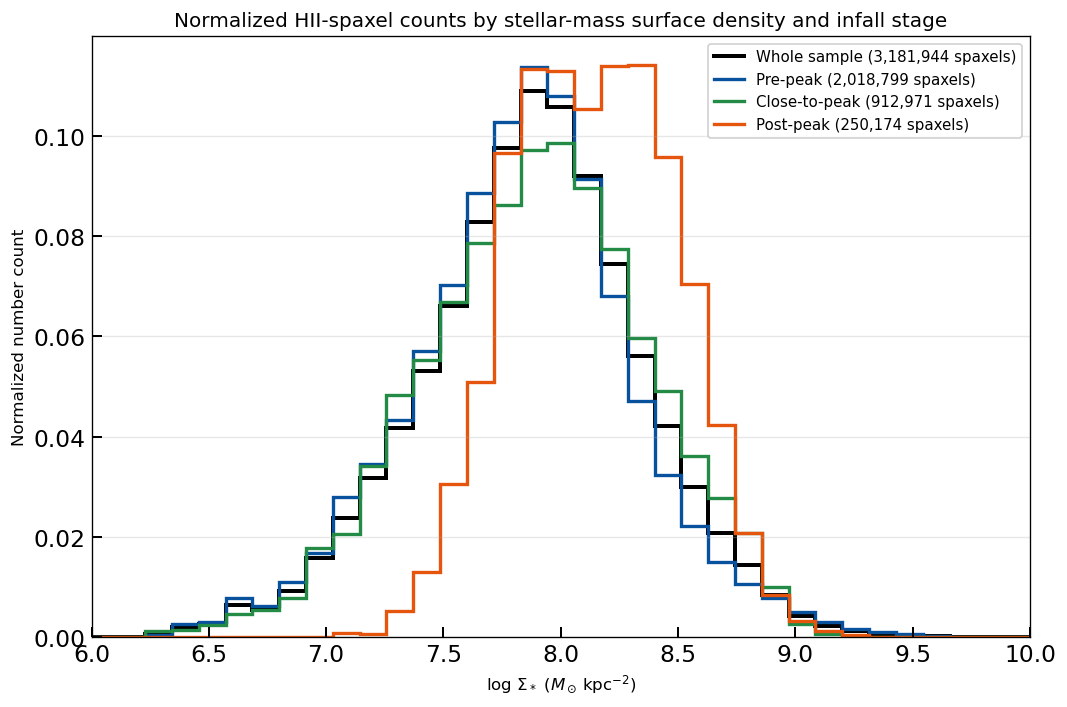

Normalization: for each curve, bin count / selected HII+EW+sigma spaxels inside the plotted mass range; bin heights sum to 1.


In [6]:
# Normalized HII-spaxel number counts versus stellar-mass surface density.
# Each curve is normalized by its own number of selected spaxels inside the
# plotted mass range, so the histogram-bin heights sum to one (not unit area).
HISTOGRAM_FULL_STYLE = {
    "color": "black",
    "linewidth": 2.4,
    "linestyle": "-",
}
HISTOGRAM_BINS_FULL = 35
HISTOGRAM_BINS_ZOOM = 20


def normalized_number_counts(values, edges, *, upper_inclusive=True):
    """Return bin counts divided by the selected count in the plotted range."""
    values = np.asarray(values, dtype=float)
    finite = np.isfinite(values)
    if upper_inclusive:
        in_range = (values >= edges[0]) & (values <= edges[-1])
    else:
        in_range = (values >= edges[0]) & (values < edges[-1])
    selected = values[finite & in_range]
    counts, _ = np.histogram(selected, bins=edges)
    normalized = counts.astype(float)
    if normalized.sum() > 0:
        normalized /= normalized.sum()
    return normalized, int(selected.size)


def aggregate_mass_samples():
    samples = [
        ("Whole sample", all_x_full, HISTOGRAM_FULL_STYLE),
    ]
    for stage in (1, 2, 3):
        samples.append(
            (
                RSFMS_STAGE_LABELS[stage],
                stage_log_sigma_m[stage],
                {
                    "color": RSFMS_STAGE_STYLE[stage]["contour"],
                    "linewidth": 2.0,
                    "linestyle": "-",
                },
            )
        )
    return samples


def plot_normalized_mass_counts(
    ax,
    mass_range,
    n_bins,
    *,
    title,
    upper_inclusive=True,
    show_legend=True,
    background=False,
):
    edges = np.linspace(mass_range[0], mass_range[1], n_bins + 1)
    for label, values, style in aggregate_mass_samples():
        normalized, n_selected = normalized_number_counts(
            values,
            edges,
            upper_inclusive=upper_inclusive,
        )
        draw_style = dict(style)
        if background:
            draw_style["linewidth"] = 0.9
            draw_style["alpha"] = 0.45
            draw_style["zorder"] = 1
        ax.stairs(
            normalized,
            edges,
            label=f"{label} ({n_selected:,} spaxels)",
            **draw_style,
        )

    ax.set(
        xlabel=r"$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$",
        ylabel="Normalized number count",
        xlim=mass_range,
        title=title,
    )
    ax.grid(True, axis="y", alpha=0.3)
    if show_legend:
        ax.legend(framealpha=0.9, fontsize=9)
    return edges


# Retain the selected mass values separately for every galaxy for the final grid.
galaxy_log_sigma_m = {}
for galaxy in full_sample_galaxies:
    maps = load_selected_rsfms_maps(galaxy)
    selected = selected_rsfms_mask(*maps)
    log_sigma_m, _, _, _ = maps
    galaxy_log_sigma_m[galaxy] = np.asarray(log_sigma_m[selected], dtype=float)

fig, ax = plt.subplots(figsize=(9, 6))
mass_edges_full = plot_normalized_mass_counts(
    ax,
    RSFMS_XRANGE,
    HISTOGRAM_BINS_FULL,
    title=(
        "Normalized HII-spaxel counts by stellar-mass surface density "
        "and infall stage"
    ),
)
aggregate_full_background = []
for label, values, style in aggregate_mass_samples():
    normalized, n_selected = normalized_number_counts(values, mass_edges_full)
    aggregate_full_background.append(
        (label, normalized, n_selected, dict(style))
    )
plt.tight_layout()
# plt.savefig(OUTDIR / "MAUVE_MUSE_normalized_HII_counts_by_mass_and_infall_stage.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_normalized_HII_counts_by_mass_and_infall_stage.pdf", bbox_inches="tight")
plt.show()

print(
    "Normalization: for each curve, bin count / selected HII+EW+sigma spaxels "
    "inside the plotted mass range; bin heights sum to 1."
)


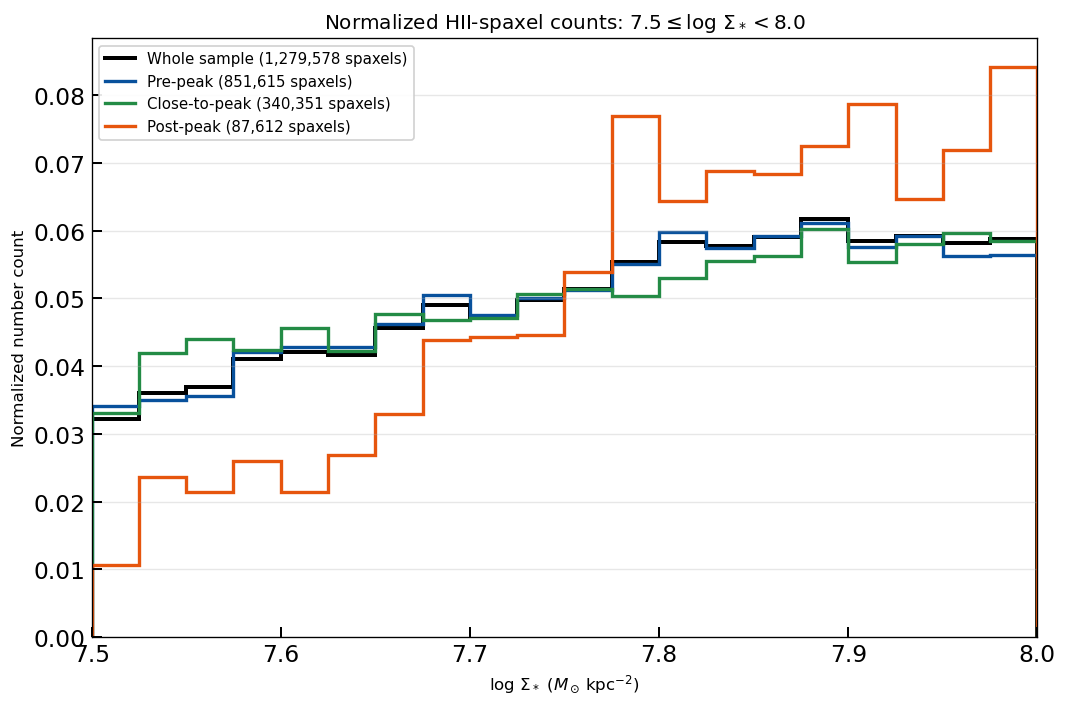

In [7]:
# Normalized HII-spaxel number counts for 7.5 <= log Sigma_* < 8.0.
MASS_RANGE = (7.5, 8.0)
fig, ax = plt.subplots(figsize=(9, 6))
plot_normalized_mass_counts(
    ax,
    MASS_RANGE,
    HISTOGRAM_BINS_ZOOM,
    upper_inclusive=False,
    title=r"Normalized HII-spaxel counts: $7.5 \leq \log\,\Sigma_* < 8.0$",
)
plt.tight_layout()
plt.show()


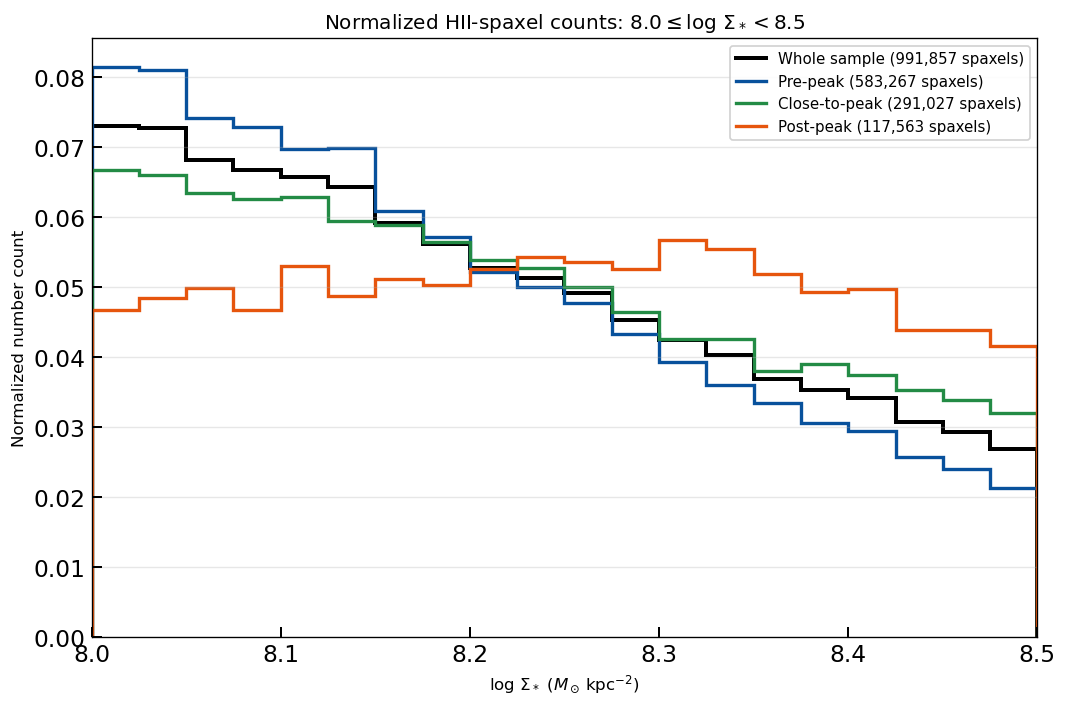

In [8]:
# Normalized HII-spaxel number counts for 8.0 <= log Sigma_* < 8.5.
MASS_RANGE = (8.0, 8.5)
fig, ax = plt.subplots(figsize=(9, 6))
plot_normalized_mass_counts(
    ax,
    MASS_RANGE,
    HISTOGRAM_BINS_ZOOM,
    upper_inclusive=False,
    title=r"Normalized HII-spaxel counts: $8.0 \leq \log\,\Sigma_* < 8.5$",
)
plt.tight_layout()
plt.show()


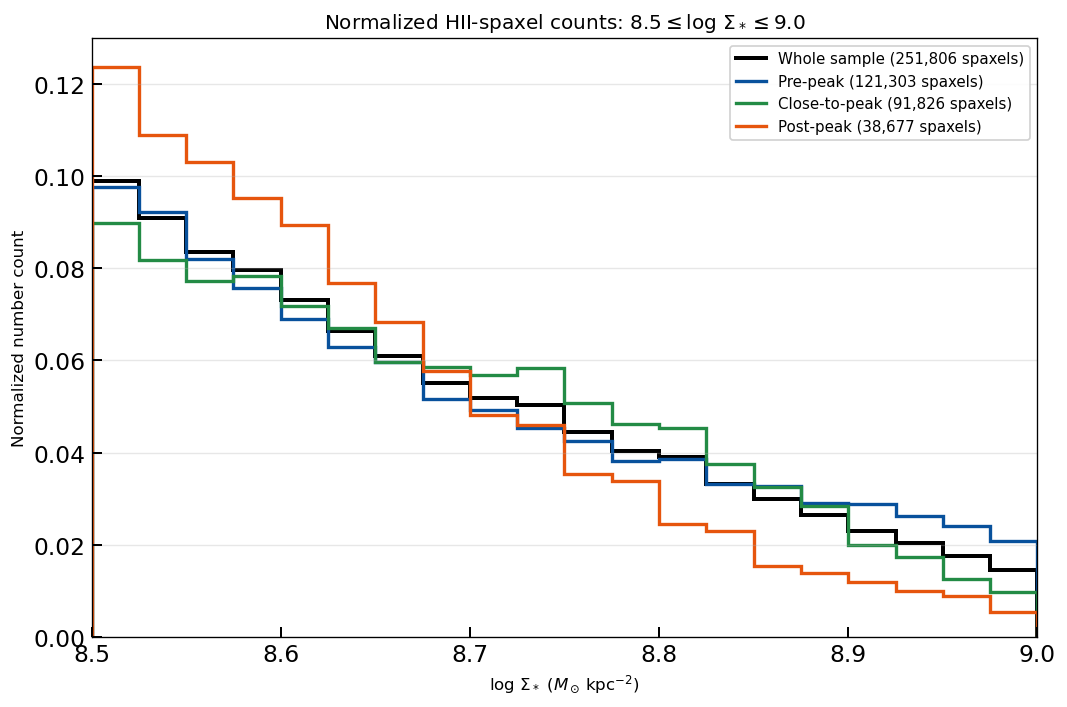

In [9]:
# Normalized HII-spaxel number counts for 8.5 <= log Sigma_* <= 9.0.
MASS_RANGE = (8.5, 9.0)
fig, ax = plt.subplots(figsize=(9, 6))
plot_normalized_mass_counts(
    ax,
    MASS_RANGE,
    HISTOGRAM_BINS_ZOOM,
    upper_inclusive=True,
    title=r"Normalized HII-spaxel counts: $8.5 \leq \log\,\Sigma_* \leq 9.0$",
)
plt.tight_layout()
plt.show()


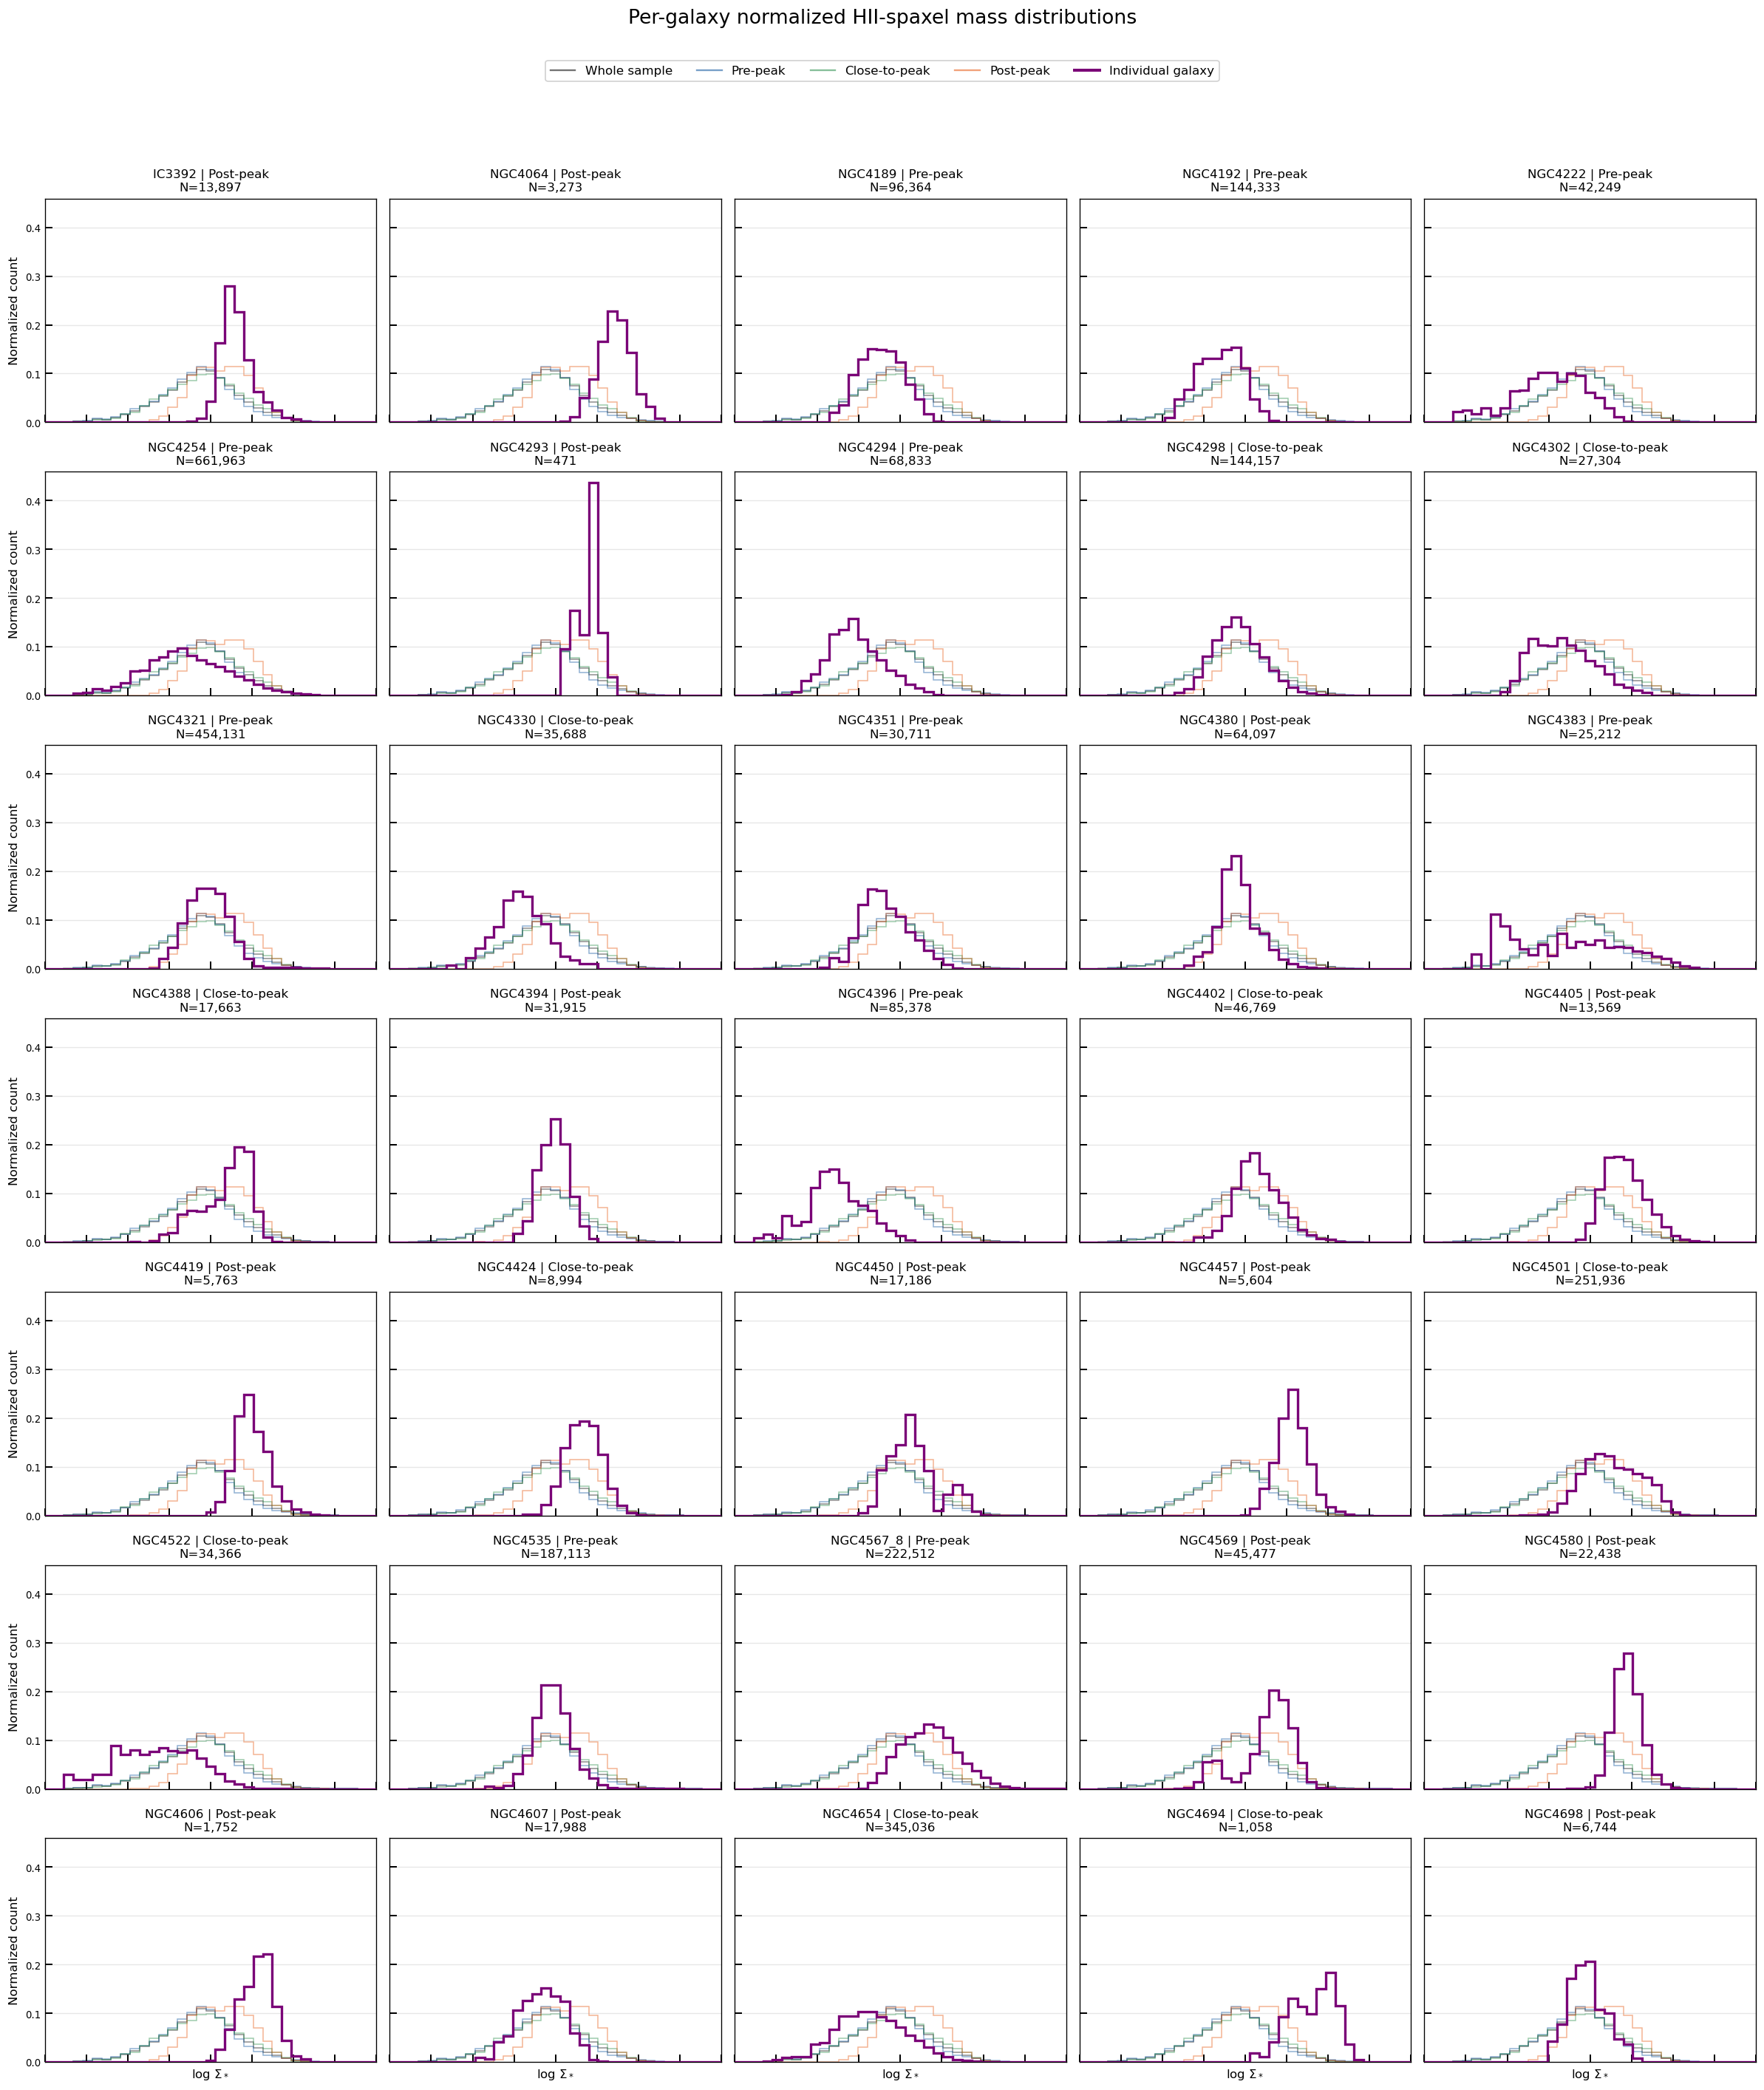

In [11]:
# Per-galaxy normalized histograms over the cell-9 aggregate background.
NROWS, NCOLS = 8, 5
if len(full_sample_galaxies) > NROWS * NCOLS:
    raise RuntimeError(
        f"The {NROWS}x{NCOLS} grid has {NROWS * NCOLS} panels but "
        f"{len(full_sample_galaxies)} galaxies were selected."
    )

fig, axes = plt.subplots(
    NROWS,
    NCOLS,
    figsize=(20, 26),
    sharex=True,
    sharey=True,
)
axes_flat = axes.ravel()
galaxy_overlay_color = "#7A0177"

for ax, galaxy in zip(axes_flat, full_sample_galaxies):
    # The four cell-9 aggregate curves are retained as a faint background.
    for label, background_counts, n_background, style in aggregate_full_background:
        ax.stairs(
            background_counts,
            mass_edges_full,
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=0.9,
            alpha=0.45,
            zorder=1,
        )
    ax.set_xlim(RSFMS_XRANGE)
    ax.grid(True, axis="y", alpha=0.3)

    values = galaxy_log_sigma_m[galaxy]
    normalized, n_selected = normalized_number_counts(values, mass_edges_full)
    ax.stairs(
        normalized,
        mass_edges_full,
        color=galaxy_overlay_color,
        linewidth=2.0,
        zorder=5,
    )
    stage = full_sample_infall_class.get(galaxy)
    stage_label = RSFMS_STAGE_LABELS.get(stage, "Unclassified")
    ax.set_title(
        f"{galaxy} | {stage_label}\nN={n_selected:,}",
        fontsize=10,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(labelsize=8)

for ax in axes_flat[len(full_sample_galaxies):]:
    ax.set_visible(False)

last_visible_row = (len(full_sample_galaxies) - 1) // NCOLS
for ax in axes[last_visible_row, :]:
    if ax.get_visible():
        ax.set_xlabel(r"$\log\,\Sigma_*$", fontsize=10)
for ax in axes[:, 0]:
    if ax.get_visible():
        ax.set_ylabel("Normalized count", fontsize=10)

background_handles = [
    Line2D([0], [0], color=style["color"], linewidth=1.4, alpha=0.55, label=label)
    for label, _, style in aggregate_mass_samples()
]
background_handles.append(
    Line2D([0], [0], color=galaxy_overlay_color, linewidth=2.4, label="Individual galaxy")
)
fig.legend(
    handles=background_handles,
    loc="upper center",
    ncol=5,
    framealpha=0.9,
    bbox_to_anchor=(0.5, 0.995),
)
fig.suptitle(
    "Per-galaxy normalized HII-spaxel mass distributions\n",
    fontsize=16,
    y=1.015,
)
fig.tight_layout(rect=[0, 0, 1, 0.975])
# plt.savefig(OUTDIR / "MAUVE_MUSE_per_galaxy_normalized_HII_mass_histograms.png", dpi=600, bbox_inches="tight")
# plt.savefig(OUTDIR / "MAUVE_MUSE_per_galaxy_normalized_HII_mass_histograms.pdf", bbox_inches="tight")
plt.show()
